# FastAPI: Async & Real-Time
**Topics:** Background Tasks · WebSockets

> Code snippets here are for understanding structure — run the `.py` files in `examples/` to see them working.

---
## PART 1 — Background Tasks

### The Problem

Some work shouldn't make the user wait. When a user registers:
- Saving to the database → must happen before responding
- Sending a welcome email → doesn't need to block the response
- Logging analytics → doesn't need to block the response

**Background tasks** run *after* the response is already sent to the client.

```
Client sends request
      ↓
FastAPI runs your endpoint
      ↓
FastAPI sends response to client  ← client gets response immediately
      ↓
FastAPI runs background task      ← happens after, client doesn't wait
```

**Real-world analogy:** You order food at a restaurant. The waiter confirms your order immediately (response). The kitchen then prepares it (background work). You don't stand at the counter waiting for confirmation — you sit down and the work happens behind the scenes.

## PART 1 — Background Tasks

### The Problem

Some work shouldn't make the user wait. When a user registers:
- Saving to the database → must happen before responding
- Sending a welcome email → doesn't need to block the response
- Logging analytics → doesn't need to block the response

**Background tasks** run *after* the response is already sent to the client.

```
Client sends request
      ↓
FastAPI runs your endpoint
      ↓
FastAPI sends response to client  ← client gets response immediately
      ↓
FastAPI runs background task      ← happens after, client doesn't wait
```

**Real-world analogy:** You order food at a restaurant. The waiter
confirms your order immediately (response). The kitchen then prepares
it (background work). You don't stand at the counter waiting for
confirmation — you sit down and the work happens behind the scenes.

---

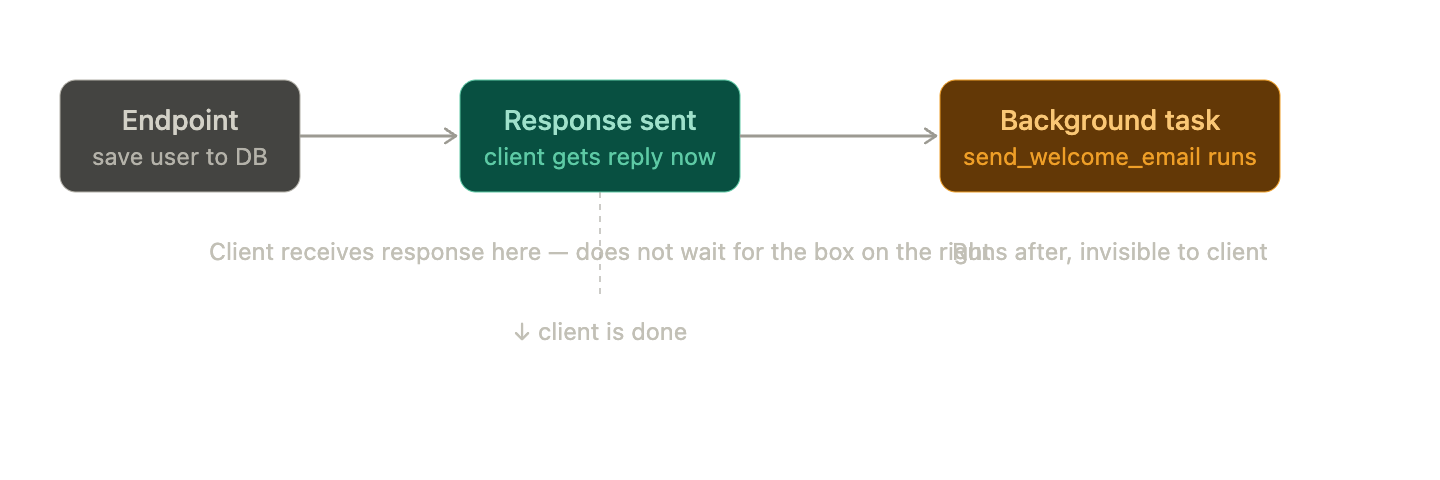
### Code Walkthrough

```python
from fastapi import FastAPI, BackgroundTasks

app = FastAPI()


def send_welcome_email(email: str, name: str):
    # this is just a NORMAL function — nothing FastAPI-specific about it
    # it only becomes "background" because of how it's scheduled below
    print(f"Sending welcome email to {email}...")
    # in reality: smtplib.sendmail() or requests.post() to an email service
    print(f"Email sent to {name} at {email}")


@app.post("/register")
def register_user(name: str, email: str, background_tasks: BackgroundTasks):
    # BackgroundTasks is a special type FastAPI recognizes by type hint —
    # it gets auto-injected, no Depends() needed, similar to how
    # Request is auto-injected in middleware

    # ① critical work — runs NOW, response waits for this to finish
    user = {"id": 1, "name": name, "email": email}

    # ② schedule the email — does NOT run yet, just gets queued
    # syntax: add_task(function_to_call, arg1, arg2, ...)
    background_tasks.add_task(send_welcome_email, email, name)

    # ③ response goes out immediately — task above hasn't executed yet
    return {"message": "Registered successfully", "user": user}
```

---

### Key Things to Understand

**`BackgroundTasks`** — a class FastAPI provides. You don't create it
yourself; you just declare it as a parameter and FastAPI hands you an
instance, the same way it hands you `Request` in middleware.

**`add_task(func, *args)`** — doesn't call `func` immediately. It just
adds it to a queue. FastAPI runs everything in that queue only after
the response has been sent.

**Why pass the function, not call it** —

```python
background_tasks.add_task(send_welcome_email, email, name)   # ✅ correct
background_tasks.add_task(send_welcome_email(email, name))   # ❌ wrong
```

The second version calls `send_welcome_email` immediately while
building the request — defeating the entire purpose. You're handing
FastAPI the *function itself* plus its arguments, so FastAPI can call
it later, on its own schedule.

---

### Timeline for One Request

```
1. register_user() runs — user dict created
2. add_task() queues send_welcome_email (does not run yet)
3. return statement executes — response object built
4. response sent to client — client's request is DONE
5. send_welcome_email() finally runs — client already moved on
```

---

> 💡 **Rule of thumb:** if the user needs the result of the work to see
> a correct response (saving data, validating something) → do it
> normally. If the work is "fire and forget" (emails, logs, notifications)
> → background task.

### 1.2 — Multiple Background Tasks

You can add as many tasks as you want — they all run **after** the
response, **in the order added**.

```python
def send_welcome_email(email: str):
    print(f"[BG] Sending welcome email to {email}")

def notify_admin(user_name: str):
    print(f"[BG] Notifying admin: new user '{user_name}' registered")

def log_signup_event(email: str):
    print(f"[BG] Logging signup event for {email} to analytics")


@app.post("/register")
def register_user(name: str, email: str, background_tasks: BackgroundTasks):
    user = {"id": 1, "name": name, "email": email}

    # queued in this order — they will RUN in this order too
    background_tasks.add_task(send_welcome_email, email)
    background_tasks.add_task(notify_admin, name)
    background_tasks.add_task(log_signup_event, email)

    return {"message": "Registered", "user": user}
```

---

### Think of `background_tasks` as a To-Do List

```
add_task() doesn't run anything — it just writes a line on the list.
FastAPI only starts checking off the list AFTER the response is sent.
```

```
add_task(send_welcome_email, email)   →  📝 task 1 added to list
add_task(notify_admin, name)          →  📝 task 2 added to list
add_task(log_signup_event, email)     →  📝 task 3 added to list

... response sent to client ...

now FastAPI works through the list, top to bottom:
✅ task 1 runs
✅ task 2 runs
✅ task 3 runs
```

---

### Timeline

```
1. register_user() builds user dict
2. 3 tasks queued — none have run yet
3. response returned and sent to client
4. client is done — already moved on
5. send_welcome_email() runs
6. notify_admin() runs
7. log_signup_event() runs
```

---

> 💡 Each `add_task()` call is independent — different function,
> different arguments. FastAPI just runs them one after another,
> in the exact order you called `add_task()`.

### 1.3 — Background Tasks with Dependencies

`BackgroundTasks` can also be used **inside a dependency** — useful when
the task needs something the dependency already has (like a DB session).

```python
from fastapi import Depends

def write_log(message: str):
    print(f"[LOG] {message}")


# dependency that ALSO schedules a background task
def log_request(background_tasks: BackgroundTasks, request_path: str = "/"):
    background_tasks.add_task(write_log, f"Request to {request_path}")


@app.get("/items")
def list_items(
    background_tasks: BackgroundTasks,
    _log = Depends(log_request)           # dependency schedules the log task
):
    return {"items": ["item1", "item2"]}
```

---

### The Key Insight — Shared `BackgroundTasks` Instance

Both `list_items` and `log_request` declare `background_tasks:
BackgroundTasks` — but it's **not two separate lists**. FastAPI creates
**one instance per request** and injects the *same* one everywhere it's
asked for.

```
list_items's background_tasks  ───┐
                                    ├──→  SAME object
log_request's background_tasks ───┘
```

So when `log_request` (the dependency) calls `add_task()`, it's adding
to the **exact same queue** that `list_items` (the endpoint) could also
add to.

---

### Why This Matters

```python
# ❌ without this trick — endpoint has to manually call the dependency's logic
@app.get("/items")
def list_items(background_tasks: BackgroundTasks):
    write_log(f"Request to /items")    # repeated everywhere, no DI benefits
    return {"items": [...]}
```

```python
# ✅ dependency handles its own logging, fully decoupled from the endpoint
@app.get("/items")
def list_items(background_tasks: BackgroundTasks, _log = Depends(log_request)):
    return {"items": [...]}            # endpoint doesn't even mention logging
```

The endpoint stays clean — it doesn't even need to know logging is
happening. The dependency owns that responsibility entirely.

---

### Timeline

```
1. FastAPI creates ONE BackgroundTasks instance for this request
2. log_request (dependency) runs first — adds write_log task to it
3. list_items (endpoint) runs — returns response
4. response sent to client
5. write_log() finally runs — using the task added back in step 2
```

---

> 💡 This is the same pattern as a DB session dependency — a
> dependency can prepare *and* schedule cleanup/follow-up work, while
> the endpoint just focuses on its own logic.

### 1.4 — Background Tasks vs Async/Await

A common confusion: both deal with "not blocking everything", but they
solve **different problems**.

| | `async def` endpoint | `BackgroundTasks` |
|---|---|---|
| When it runs | During the request | After the response |
| Client waits? | ✅ Yes | ❌ No |
| Use for | Non-blocking I/O (DB, external API) | Fire-and-forget (email, logging) |

---

### The Core Difference

```python
# async/await — client STILL WAITS, just doesn't freeze the server
@app.get("/data")
async def get_data():
    result = await fetch_from_db()   # server can handle other requests
    return result                    # meanwhile, but THIS client waits
                                      # until fetch_from_db() finishes


# background task — client does NOT wait at all
@app.post("/order")
def place_order(background_tasks: BackgroundTasks):
    background_tasks.add_task(send_confirmation_email)  # scheduled
    return {"order": "placed"}   # returned immediately, email comes later
```

`async`/`await` is about **not blocking the server** while still
making the client wait for that one operation's result.
`BackgroundTasks` is about **not making the client wait at all** for
something they don't need to see the result of.

---

### Simple Test to Pick the Right One

```
Does the response depend on this work finishing?

YES → use async/await (client needs the result)
NO  → use BackgroundTasks (client doesn't care when it finishes)
```

```
fetch_from_db()          → response NEEDS the data        → async/await
send_confirmation_email() → response doesn't need this     → BackgroundTasks
```

---

### ⚠️ Important Limitation

```
BackgroundTasks runs in the SAME process as your server.
```

Fine for: quick emails, logging, small notifications.
**Not fine for:** video processing, ML inference, anything heavy or slow —
it'll tie up server resources just like a regular function would.

> For heavy background work, use a proper task queue like
> **Celery + Redis** instead — runs in a separate worker process,
> won't compete with your API for resources.

---

> 💡 One-liner: **async/await** = "do this efficiently while the client
> waits." **BackgroundTasks** = "do this later, client doesn't wait at all."

## PART 2 — WebSockets

### HTTP vs WebSocket

**HTTP** is a request-response protocol — client asks, server answers,
connection closes. Every new request means a brand new connection.

```
Client → "GET /messages"   → Server
Client ← {messages: [...]} ← Server
       [connection closed]
```

**WebSocket** is a persistent, two-way connection — both sides can send
messages at any time, no new request needed.

```
Client ←→ Server   [connection stays open]
Client → "Hello"   → Server
Client ← "Hi back" ← Server
Client ← "New msg" ← Server   (server pushes without client asking)
Client → "Bye"     → Server
       [connection closed by either side]
```

---

### The Core Difference

```
HTTP       → ask, get answer, done — one-shot
WebSocket  → stay connected, talk anytime — ongoing
```

The biggest shift: with HTTP, the **server can never speak first** —
it only ever replies to a request. With WebSocket, the **server can
push data on its own**, whenever something happens.

---

### HTTP and Websocket connection open/close
HTTP:
- opens automatically when request is made
- closes automatically when response is sent
- you write zero code for opening or closing
- FastAPI handles it entirely

WebSocket:
- opens when client calls new WebSocket("ws://...")  ← explicit
- stays open until someone closes it                 ← must be explicit
- closes when:
    - client calls ws.close()                        ← explicit
    - server calls await websocket.close()           ← explicit
    - network failure                                ← forced, not by choice


### When to Use WebSockets

```
✅ Live chat
✅ Real-time notifications
✅ Live dashboards (stock prices, sports scores)
✅ Multiplayer games
✅ Collaborative tools (Google Docs style)
```

### When NOT to Use WebSockets

```
❌ Normal CRUD operations — HTTP is simpler and sufficient
❌ One-time data fetch — no benefit to keeping a connection open
```

---

> 💡 Rule of thumb: if the server needs to **push** updates without the
> client asking first, use WebSocket. If it's just "ask, get answer,"
> stick with HTTP.

### 2.1 — Basic WebSocket Endpoint

```python
from fastapi import WebSocket

@app.websocket("/ws")
async def websocket_endpoint(websocket: WebSocket):
    await websocket.accept()           # ① complete handshake — connection now open

    try:
        while True:                    # ② keep connection alive — loop forever
            data = await websocket.receive_text()            # ③ wait for client message
            await websocket.send_text(f"You said: {data}")   # ④ send a reply back
    except Exception:
        pass                           # ⑤ client disconnected — loop breaks here
    finally:
        await websocket.close()        # ⑥ clean up the connection
```

---

### Why the `while True` Loop?

In a normal HTTP route, the function runs **once** and returns. A
WebSocket route doesn't return after one message — it has to **stay
alive** for the whole conversation. `while True` is what keeps the
function (and the connection) running until the client leaves.

```
HTTP endpoint      → runs once → done
WebSocket endpoint → runs in a loop → stays open → exits only on disconnect
```

---

### Why `try / except / finally`?

The client can disconnect at **any point** — mid-message, mid-loop,
anytime. When that happens, `receive_text()` raises an exception
instead of returning a value. The `try/except` catches that
disconnect gracefully instead of crashing the server, and `finally`
guarantees `close()` runs no matter how the loop ended.

```
client closes tab  →  receive_text() throws  →  except catches it  →  finally cleans up
```

---

### WebSocket Methods Cheat Sheet

```python
websocket.accept()           # complete the connection handshake
websocket.receive_text()     # wait for a text message from client
websocket.receive_json()     # wait for a JSON message from client
websocket.receive_bytes()    # wait for binary data from client
websocket.send_text(msg)     # push text to client
websocket.send_json(data)    # push JSON to client
websocket.close()            # close the connection
```

---

### Timeline for One Connection

```
1. client connects to /ws
2. accept() — handshake completes, connection open
3. loop starts, waits at receive_text()
4. client sends "hi" → server replies "You said: hi"
5. loop goes back to waiting — repeats for every message
6. client disconnects → exception raised → except catches it
7. finally → close() runs, connection fully cleaned up
```

---

> 💡 The connection is **one long conversation**, not a series of
> separate requests — that's why the structure looks so different from
> a regular `@app.get()` route.

### 2.2 — Connection Manager (handling multiple clients)

A single `websocket` variable only knows about **one** client. To
broadcast messages to everyone connected, you need to **track all
active connections** somewhere — that's what `ConnectionManager` does.

```python
from typing import List

class ConnectionManager:
    def __init__(self):
        self.active_connections: List[WebSocket] = []   # all currently connected clients

    async def connect(self, websocket: WebSocket):
        await websocket.accept()                        # complete the handshake
        self.active_connections.append(websocket)        # start tracking this client

    def disconnect(self, websocket: WebSocket):
        self.active_connections.remove(websocket)         # stop tracking this client

    async def send_personal(self, message: str, websocket: WebSocket):
        await websocket.send_text(message)                # message goes to ONE client only

    async def broadcast(self, message: str):
        for connection in self.active_connections:        # loop through EVERY client
            await connection.send_text(message)            # send the same message to each

manager = ConnectionManager()   # one shared instance — same list for the whole app
```

---

### Mental Model

```
active_connections = [client1, client2, client3]

send_personal(msg, client1)  → only client1 gets it
broadcast(msg)                → client1, client2, client3 ALL get it
```

Think of it as a **group chat membership list** — `connect()` adds
someone to the room, `disconnect()` removes them, `broadcast()` shouts
to everyone currently in the room.

> 💡 `manager` is created **once**, outside any route — every WebSocket
> connection in the app shares this same list.

### 2.3 — Live Chat with Connection Manager

Builds directly on `manager` from 2.2 — this endpoint just connects a
specific user, listens for their messages, and broadcasts them.

```python
from fastapi import WebSocketDisconnect

@app.websocket("/ws/chat/{username}")
async def chat_endpoint(websocket: WebSocket, username: str):
    await manager.connect(websocket)                                  # accept + start tracking
    await manager.broadcast(f"[System] {username} joined the chat")   # tell everyone

    try:
        while True:
            message = await websocket.receive_text()             # wait for this user's message
            await manager.broadcast(f"{username}: {message}")   # send to everyone

    except WebSocketDisconnect:
        # raised automatically when this client closes the tab/connection
        manager.disconnect(websocket)
        await manager.broadcast(f"[System] {username} left the chat")
```

---

### Mental Model

```
gaurab connects  → manager.connect()   → added to active_connections
gaurab sends "hi" → manager.broadcast() → "gaurab: hi" sent to everyone
gaurab closes tab → WebSocketDisconnect → manager.disconnect() → removed
```

`{username}` is just a normal path param — each connecting user runs
their own copy of `chat_endpoint()`, but all of them share the same
`manager`, so messages cross between every open connection.

> 💡 `WebSocketDisconnect` is the specific signal for "client closed
> the tab" — using it instead of a generic `Exception` means real bugs
> in your code still surface instead of being silently swallowed.

### 2.4 — WebSocket with JSON Messages

Real apps usually send structured JSON instead of plain text — easier
to handle on the frontend.

```python
@app.websocket("/ws/live")
async def live_endpoint(websocket: WebSocket):
    await websocket.accept()                          # complete handshake — connection open

    try:
        while True:                                    # keep listening for as long as client stays connected
            data = await websocket.receive_json()       # wait for client message, auto-parsed into a dict
            # data = {"type": "message", "content": "hello"}

            msg_type = data.get("type")                 # check what KIND of message this is

            if msg_type == "ping":
                await websocket.send_json({"type": "pong"})   # heartbeat reply — confirms connection is alive

            elif msg_type == "message":
                await websocket.send_json({
                    "type": "echo",                      # tells client what kind of message THIS is
                    "content": data.get("content"),       # echo back whatever they sent
                    "from": "server"
                })

    except WebSocketDisconnect:
        pass                                             # client closed tab — just exit quietly, nothing to clean up here
```

---

### Why `type` Field? — One Endpoint, Many Behaviors

Plain text only gives you a string — no way to tell what *kind* of
message it is without parsing it yourself. JSON lets you attach a
`"type"` field so one endpoint can branch into different behaviors:

```
{"type": "ping"}                        → server replies with pong (heartbeat check)
{"type": "message", "content": "hi"}    → server echoes it back
{"type": "typing"}                      → could trigger a "user is typing..." indicator
```

```
receive_text() → just a raw string, you decide what it means
receive_json()  → structured dict, "type" tells you what to DO with it
```

---

### Mental Model

```
client sends:  {"type": "ping"}
server checks: msg_type == "ping"  →  True
server sends:  {"type": "pong"}
```

Same `while True` + `try/except WebSocketDisconnect` shape as before —
only difference is `receive_json()`/`send_json()` instead of the text
versions, plus an `if/elif` to route based on `"type"`.

> 💡 `"ping"`/`"pong"` is a common pattern to check the connection is
> still alive — frontend sends `ping` every few seconds, if no `pong`
> comes back, it knows the connection dropped.

### 2.5 — Testing WebSockets

Swagger UI (`/docs`) does **not** support WebSockets — it only handles
HTTP requests. You need a different tool to actually open a WebSocket
connection and send/receive messages.

---

### 1. Browser Console (quickest)

```javascript
const ws = new WebSocket("ws://localhost:8000/ws/chat/Alice")  // open connection
ws.onmessage = (e) => console.log(e.data)                       // log every incoming message
ws.send("Hello from browser")                                    // send a message
```

Paste this directly into DevTools console on any open tab —
no extra setup needed.

---

### 2. HTML Test Page

A simple HTML file with JS like the snippet above, served by your
FastAPI app itself (e.g. `websockets_example.py` serving it at
`http://localhost:8000`). Useful when you want a proper UI with input
boxes and a message log instead of typing into the console.

---

### 3. `wscat` (CLI Tool)

```bash
npm install -g wscat
wscat -c ws://localhost:8000/ws/chat/Alice
```

Opens an interactive terminal session — type a message, hit enter, see
the reply. Good for quick backend-only testing without touching a
browser at all.

---

### Quick Comparison

| Method | Best for |
|---|---|
| Browser console | Fastest, no install, good for one-off checks |
| HTML test page | Demoing to others, simulating a real frontend |
| `wscat` | Terminal-only testing, scripting, CI checks |

> 💡 `ws://` is the WebSocket equivalent of `http://` — use `wss://`
> (like `https://`) for secure connections in production.

---
## Key Takeaways

| Concept | What to remember |
|---|---|
| **BackgroundTasks** | Runs after response is sent — client doesn't wait |
| **`add_task(fn, *args)`** | Schedule a function to run in background |
| **Multiple tasks** | All added tasks run in order after response |
| **BG tasks vs async** | async = non-blocking but client still waits; BG = runs after response |
| **WebSocket** | Persistent two-way connection — both sides can push messages anytime |
| **`websocket.accept()`** | Must call this first to complete the handshake |
| **ConnectionManager** | Class to track all connected clients and broadcast to them |
| **`WebSocketDisconnect`** | Exception raised when client disconnects — always handle this |
| **Testing WS** | Use browser console or HTML page — Swagger doesn't support WebSockets |

### What to run next
```bash
cd backend-and-systems/fastapi/examples
uvicorn background_tasks_example:app --reload   # then open /docs
uvicorn websockets_example:app --reload         # then open http://127.0.0.1:8000
```